# DATASET DOWNLOAD

In [ ]:
from huggingface_hub import login, hf_hub_download
import os


print(" Logging into Hugging Face...")
login(token='') 

print(" Downloading datasets...")

hf_hub_download(
    repo_id="Harsh2005/DeepFashion2-Pruned", 
    filename="train_clean.zip", 
    repo_type="dataset", 
    local_dir="/kaggle/working"
)

hf_hub_download(
    repo_id="Harsh2005/DeepFashion2-Pruned", 
    filename="validation_clean.zip", 
    repo_type="dataset", 
    local_dir="/kaggle/working"
)

print(" Unzipping files...")
!unzip -q /kaggle/working/train_clean.zip -d /kaggle/working/train
!unzip -q /kaggle/working/validation_clean.zip -d /kaggle/working/val


import os


    

print("✅ Data is ready!")

 Logging into Hugging Face...


train_clean.zip:   0%|          | 0.00/7.99G [00:00<?, ?B/s]

validation_clean.zip:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

 Unzipping files...
✅ Data is ready!


In [2]:

if os.path.exists("/kaggle/working/train_clean.zip"):
    os.remove("/kaggle/working/train_clean.zip")
    print(" Deleted train_clean.zip")

if os.path.exists("/kaggle/working/validation_clean.zip"):
    os.remove("/kaggle/working/validation_clean.zip")
    print(" Deleted validation_clean.zip")

 Deleted train_clean.zip
 Deleted validation_clean.zip


# TASK 3.1 : CLASSIFICATION

## Data Preprocessing

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import json
import os
from glob import glob


CATEGORIES = ["short sleeve top", "trousers", "shorts", "long sleeve top", "skirt"]
CAT_TO_IDX = {cat: i for i, cat in enumerate(CATEGORIES)}


class DeepFashionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.json_paths = glob(os.path.join(root_dir, '**/*.json'), recursive=True)
        
    def __len__(self): 
        return len(self.json_paths)

    def __getitem__(self, idx):
        json_path = self.json_paths[idx]
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        
        labels = torch.zeros(len(CATEGORIES), dtype=torch.float32)
        for key, value in data.items():
            if key.startswith('item') and isinstance(value, dict):
                cat_name = value.get('category_name')
                if cat_name in CAT_TO_IDX:
                    labels[CAT_TO_IDX[cat_name]] = 1.0
        
        
        img_path = json_path.replace('.json', '.jpg').replace('annos', 'image')
        if not os.path.exists(img_path):
            img_path = json_path.replace('.json', '.jpg')
        
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labels


train_ts = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(15),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_ts = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_set = DeepFashionDataset('/kaggle/working/train/train', train_ts)
val_set = DeepFashionDataset('/kaggle/working/val/validation', val_ts)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)

print(f"✅ Setup Complete.")
print(f"Found {len(train_set)} training samples and {len(val_set)} validation samples.")

✅ Setup Complete.
Found 144174 training samples and 23741 validation samples.


## Evaluation Metrics

In [4]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import numpy as np

def calculate_metrics(y_true, y_prob):
    # Threshold at 0.5 for classification 
    y_pred = (y_prob > 0.5).astype(int)
    
    # Per-class and averaged F1-scores 
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)[2]
 
    auc_scores = []
    for i in range(y_true.shape[1]):
        try:
            auc_scores.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
        except ValueError:
            auc_scores.append(0.5) 
            
    return precision, recall, f1, micro_f1, auc_scores

def validate(model, loader, criterion, device):
    model.eval()
    all_labels, all_preds, val_loss = [], [], 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            all_labels.append(labels.cpu())
            all_preds.append(torch.sigmoid(outputs).cpu())
            
    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_preds).numpy()
    
    prec, rec, f1_ma, f1_mi, aucs = calculate_metrics(y_true, y_prob)
    return val_loss/len(loader), f1_ma, f1_mi, aucs

## Model traning

### Transfer Learning with Fine Tuning deeper layers

In [5]:
import torch
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# --- FOCAL LOSS DEFINITION ---
class FocalLoss(nn.Module):
    def __init__(self, pos_weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        # We pass pos_weight to bce_with_logits to properly scale positive examples
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none', pos_weight=self.pos_weight
        )
        # Calculate pt
        pt = torch.exp(-F.binary_cross_entropy_with_logits(inputs, targets, reduction='none'))
        focal_loss = ((1 - pt) ** self.gamma) * bce_loss
            
        return focal_loss.mean()

# --- MODEL SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
strategy = "fine_tune_3_layers" 

model = models.resnet50(weights='IMAGENET1K_V1')

# Unfreeze layer2, layer3, layer4, and fc
for name, param in model.named_parameters():
    if "layer2" in name or "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
        
# Standard Final Layer
model.fc = nn.Linear(model.fc.in_features, len(CATEGORIES))
model = model.to(device)

# Initialize Custom Focal Loss
pos_weight_tensor = torch.tensor([1.01, 1.60, 2.93, 2.99, 3.67]).to(device)
criterion = FocalLoss(pos_weight=pos_weight_tensor, gamma=2.0)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

epochs = 15
best_val_loss = float('inf')
patience, patience_counter = 4, 0

print(f"Starting Final Deep Fine-Tuning (Focal Loss + BN Fix)...")

# --- TRAINING LOOP ---
for epoch in range(1, epochs + 1):
    model.train()
    
    # 🔥 THE BN FIX: Force BatchNorm layers in frozen blocks to stay in eval mode
    for name, m in model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            if not any(layer in name for layer in ["layer2", "layer3", "layer4"]):
                m.eval()

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        
    v_loss, f1_ma, f1_mi, aucs = validate(model, val_loader, criterion, device)
    scheduler.step(f1_ma)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch} | LR: {current_lr:.6f} | Val Loss: {v_loss:.4f} | Macro-F1: {f1_ma:.4f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"resnet50_{strategy}.pth")
        print("   -> New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 224MB/s]


Starting Final Deep Fine-Tuning (Focal Loss + BN Fix)...


Epoch 1/15: 100%|██████████| 2253/2253 [11:29<00:00,  3.27it/s]


Epoch 1 | LR: 0.000100 | Val Loss: 0.0952 | Macro-F1: 0.8168
   -> New best model saved!


...

Epoch 7 | LR: 0.000025 | Val Loss: 0.0850 | Macro-F1: 0.8592


Epoch 8/15: 100%|██████████| 2253/2253 [11:13<00:00,  3.35it/s]


Epoch 8 | LR: 0.000025 | Val Loss: 0.0881 | Macro-F1: 0.8641


Epoch 9/15: 100%|██████████| 2253/2253 [11:19<00:00,  3.32it/s]


Epoch 9 | LR: 0.000025 | Val Loss: 0.0950 | Macro-F1: 0.8661
Early stopping triggered.



🚀 GENERATING FINAL EVALUATION


Testing Final Model: 100%|██████████| 371/371 [01:31<00:00,  4.03it/s]



🔍 Auto-Tuning Thresholds for Maximum F1...
   -> short sleeve top: Best Threshold = 0.45 (F1: 0.901)
   ->         trousers: Best Threshold = 0.50 (F1: 0.912)
   ->           shorts: Best Threshold = 0.60 (F1: 0.842)
   ->  long sleeve top: Best Threshold = 0.50 (F1: 0.815)
   ->            skirt: Best Threshold = 0.55 (F1: 0.880)

--- Final Model Classification Report ---
                  precision    recall  f1-score   support

short sleeve top       0.87      0.93      0.90     12371
        trousers       0.90      0.92      0.91      9494
          shorts       0.87      0.82      0.84      4133
 long sleeve top       0.78      0.86      0.82      5916
           skirt       0.87      0.89      0.88      6499

       micro avg       0.86      0.90      0.88     38413
       macro avg       0.86      0.88      0.87     38413
    weighted avg       0.86      0.90      0.88     38413
     samples avg       0.87      0.90      0.87     38413



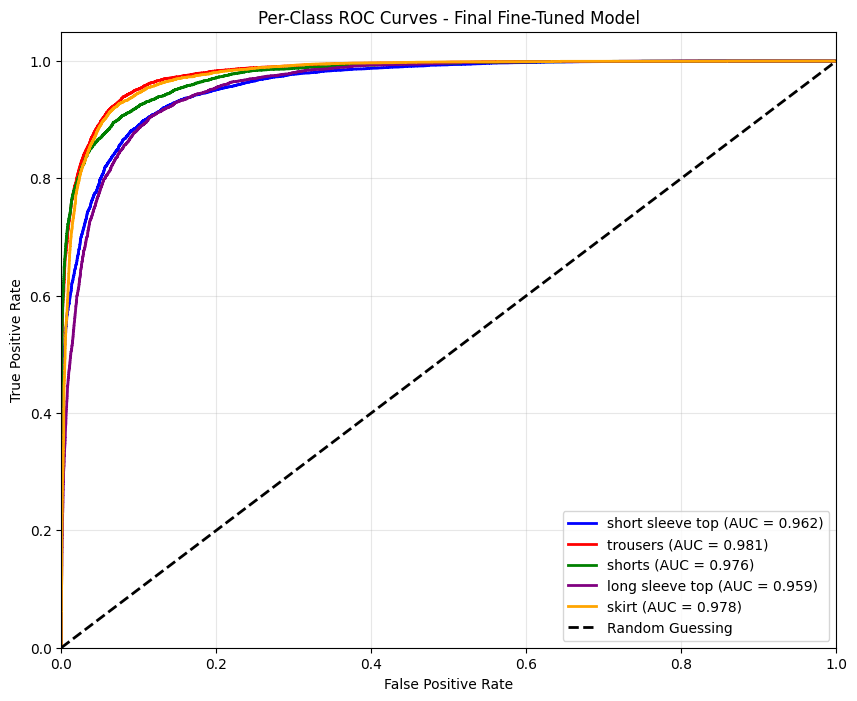

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, f1_score
import numpy as np

def find_best_thresholds(y_true, y_prob, categories):
    print("\n🔍 Auto-Tuning Thresholds for Maximum F1...")
    best_thresholds = np.zeros(y_true.shape[1])
    
    for i in range(y_true.shape[1]):
        best_f1, best_thresh = 0, 0.5
        for thresh in np.arange(0.1, 0.95, 0.05):
            y_pred_temp = (y_prob[:, i] > thresh).astype(int)
            current_f1 = f1_score(y_true[:, i], y_pred_temp, zero_division=0)
            if current_f1 > best_f1:
                best_f1 = current_f1
                best_thresh = thresh
                
        best_thresholds[i] = best_thresh
        print(f"   -> {categories[i]:>16}: Best Threshold = {best_thresh:.2f} (F1: {best_f1:.3f})")
    return best_thresholds

def generate_ultimate_report(model_path, loader):
    print(f"\n{'='*40}")
    print("🚀 GENERATING FINAL EVALUATION")
    print(f"{'='*40}")
    
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CATEGORIES))
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    model.eval() 
    
    all_labels, all_probs = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Testing Final Model"):
            imgs = imgs.to(device)
            probs = torch.sigmoid(model(imgs)).cpu().numpy()
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs)
    
    y_true = np.vstack(all_labels)
    y_prob = np.vstack(all_probs)
    
    # Apply optimal thresholds instead of a flat 0.5
    optimal_thresholds = find_best_thresholds(y_true, y_prob, CATEGORIES)
    y_pred = (y_prob > optimal_thresholds).astype(int)
    
    print("\n--- Final Model Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=CATEGORIES, zero_division=0))
    
    # --- PLOT PER-CLASS ROC ---
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, color in enumerate(colors):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{CATEGORIES[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Per-Class ROC Curves - Final Fine-Tuned Model')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    plt.savefig('final_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the final evaluation
generate_ultimate_report("resnet50_fine_tune_3_layers.pth", val_loader)